# Data preparation

In [39]:
from utils import load_data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
sns.set_theme(style="darkgrid")

In [40]:
df = load_data("police")
df.head()

,id,road_category,road_number,date,time,accident_type,collision_type,fixed_obstacle_type,accident_character,responsibility,...,accident_type_label,collision_type_label,fixed_obstacle_type_label,accident_character_label,driver_alcohol_level,driver_alcohol_detected,year,month,day_of_week,hour
0,60040220005,0.0,1.0,2022-01-31,1615,1,4,0,1,1,...,Moving vehicle,Rear,N/A,Injury/Fatality,no_alcohol,0,2022,1,Monday,16
1,60040220014,0.0,1.0,2022-02-21,2560,3,0,4,2,1,...,Fixed object,N/A,Guardrail,Material Damage Only,not_tested,<NA>,2022,2,Monday,<NA>
2,60040220020,0.0,1.0,2022-04-21,405,1,4,0,1,1,...,Moving vehicle,Rear,N/A,Injury/Fatality,no_alcohol,0,2022,4,Thursday,4
3,60040220030,0.0,1.0,2022-05-25,1015,1,4,0,2,1,...,Moving vehicle,Rear,N/A,Material Damage Only,no_alcohol,0,2022,5,Wednesday,10
4,60040220035,0.0,1.0,2022-06-06,2150,6,0,0,2,4,...,Domestic animal,N/A,N/A,Material Damage Only,not_tested,<NA>,2022,6,Monday,21


In [41]:
target = "accident_character_label"

In [42]:
leakage_features = [
    "fatalities",
    "serious_injuries",
    "minor_injuries",
    "total_material_damage",
    "extrication_method",
    "post_accident_vehicle_state",
    "leakage",
    "damage_on_vehicle",
    "accident_character"
]

drop_features = [
    "id",
    "date",   # already have month/day/week and so on
    "geom",
    "geog",
    "x",
    "y",      # not a spatial model
    target
] + leakage_features

In [43]:
df_model = df.drop(columns=[col for col in drop_features if col in df.columns]).copy()

y = df[target].copy()
X = df_model.copy()

X["hour"] = pd.to_numeric(X["hour"], errors="coerce")
X["vehicle_year"] = pd.to_numeric(X["vehicle_year"], errors="coerce")

In [53]:
categorical_cols = [
    "location_admin",
    "region",
    "district",
    "police_unit",
    "locality_type",
    "locality_type_label",
    
    "accident_type",
    "accident_type_label",
    "collision_type",
    "collision_type_label",
    "fixed_obstacle_type",
    "fixed_obstacle_type_label",
    "animal_type",

    "accident_character",
    "accident_character_label",
    "responsibility",

    "alcohol_at_driver",
    "driver_alcohol_level",
    "driver_alcohol_detected",
    "drugs_at_driver",

    "main_cause",

    "road_surface_type",
    "road_surface_condition",
    "road_condition",
    "weather_conditions",
    "visibility",
    "sight_conditions",
    "road_division",

    "accident_position_on_road",
    "traffic_control",
    "local_priority_arrangement",
    "specific_places",
    "road_geometry",

    "pedestrian_category",
    "pedestrian_reflective",
    "pedestrian_on_micromobility",
    "pedestrian_state",
    "pedestrian_alcohol",
    "pedestrian_drug_type",
    "pedestrian_behaviour",
    "pedestrian_outcome",
    "pedestrian_gender",
    "pedestrian_nationality",
    "first_aid_given",
    "pedestrian_consequences",

    "place_of_accident",
    "road_category",
    "road_number",
    "crossing_road_type",

    "vehicle_type",
    "vehicle_make",
    "vehicle_info",
    "fuel_type",
    "tire_type",
    "vehicle_owner_type",
    "skid",

    "post_accident_vehicle_state",
    "leakage",
    "extrication_method",
    "vehicle_position",
    "damage_on_vehicle",

    "driver_category",
    "driver_condition",
    "external_influence_on_driver",

    "in_vehicle_consequences",
    "person_role",
    "person_detail",
    "person_gender",
    "person_nationality",
    "person_first_aid",
    "person_consequences",

    "day_of_week"
]

numeric_cols = [
    "fatalities",
    "serious_injuries",
    "minor_injuries",
    "total_material_damage",
    "number_vehicles",
    "vehicle_year",
    "pedestrian_age",
    "person_age",
    "year",
    "month",
    "hour"
]

numeric_cols = [col for col in numeric_cols if col not in drop_features and col in X.columns]
categorical_cols = [col for col in categorical_cols if col not in drop_features and col in X.columns]


In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Pipelines
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [ ]:
from sklearn.model_selection import train_test_split

X = X.convert_dtypes()
X = X.replace({pd.NA: np.nan})

# split the set in statified manner, as target is not 50/50 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.replace({pd.NA: np.nan})
X_test = X_test.replace({pd.NA: np.nan})
y_train = y_train.replace({pd.NA: np.nan}) if isinstance(y_train, pd.Series) else y_train


for col in X.columns:
    if X[col].astype(str).str.contains("<NA>").any():
        print(col, X[col].dtype)


driver_alcohol_detected Int8


# Feature Importance via Random Forest

### Model Creation and fitting

In [64]:
from sklearn.ensemble import RandomForestClassifier


rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Model learning
rf_pipeline.fit(X_train, y_train)

TypeError: boolean value of NA is ambiguous

### Model evaluation

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf_pipeline.predict(X_test)
pos_index = list(rf_pipeline.classes_).index("Injury/Fatality")
y_proba = rf_pipeline.predict_proba(X_test)[:, pos_index]
print(classification_report(y_test, y_pred))

print(rf_pipeline.classes_)

if y_proba is not None:
    # choose positive class index if needed
    print("ROC-AUC:", roc_auc_score((y_test == "Injury/Fatality").astype(int), y_proba))

                      precision    recall  f1-score   support

     Injury/Fatality       0.82      0.80      0.81      1236
Material Damage Only       0.92      0.93      0.93      3125

            accuracy                           0.89      4361
           macro avg       0.87      0.87      0.87      4361
        weighted avg       0.89      0.89      0.89      4361

['Injury/Fatality' 'Material Damage Only']
ROC-AUC: 0.9593232362459548


### Feature importance

In [ ]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# print(fi_df.head(20))

print(fi_df.to_string())

import matplotlib.pyplot as plt

                                                          feature    importance
7                                          num__alcohol_at_driver  7.026550e-02
73                           cat__driver_alcohol_level_not_tested  6.708516e-02
47                        cat__accident_type_label_Parked vehicle  5.924201e-02
72                           cat__driver_alcohol_level_no_alcohol  5.866764e-02
2                                                       num__time  5.237743e-02
3                                              num__accident_type  5.204230e-02
8                                                 num__main_cause  4.793742e-02
24                                              num__vehicle_type  3.539755e-02
19                                           num__specific_places  3.341410e-02
48                            cat__accident_type_label_Pedestrian  3.326870e-02
5                                        num__fixed_obstacle_type  2.788833e-02
25                                      

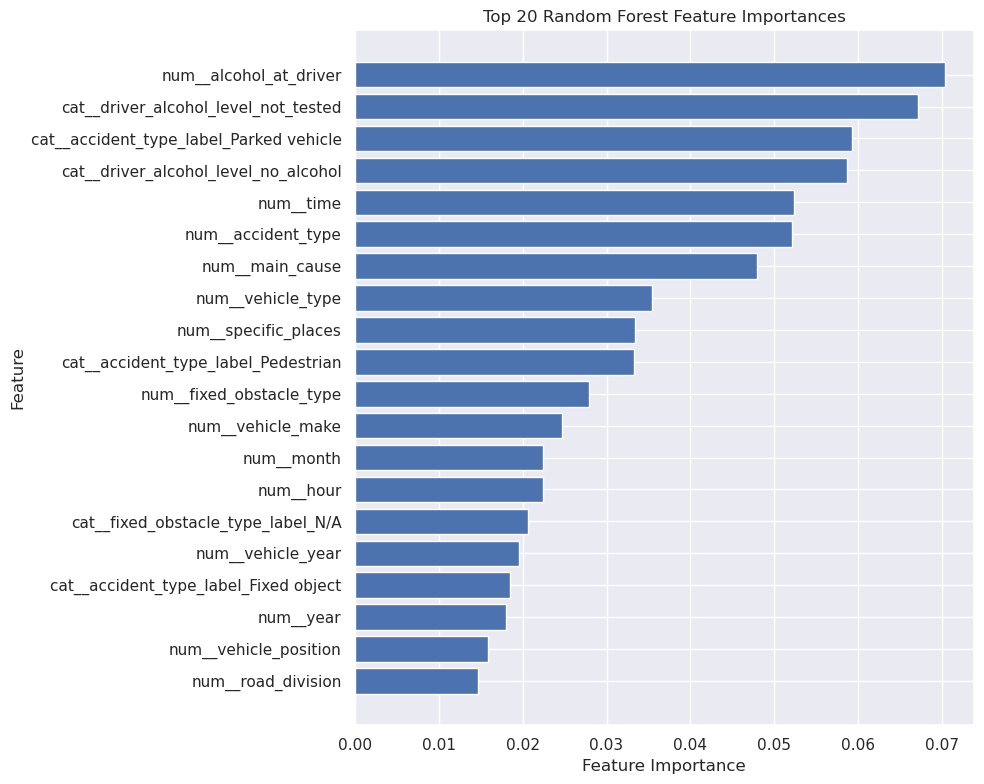

In [ ]:
top_n = 20
top_fi = fi_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
def extract_original_feature_name(transformed_name):
    # examples:
    # num__hour -> hour
    # cat__collision_type_label_Rear -> collision_type_label
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "")
    elif transformed_name.startswith("cat__"):
        rest = transformed_name.replace("cat__", "")
        
        # try to match original categorical column names
        for col in categorical_cols:
            prefix = col + "_"
            if rest.startswith(prefix):
                return col
        return rest
    return transformed_name

fi_df["original_feature"] = fi_df["feature"].apply(extract_original_feature_name)

grouped_fi = (
    fi_df.groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
) # type: ignore

print(grouped_fi.head(20))

             original_feature  importance
2         accident_type_label    0.136680
10       driver_alcohol_level    0.129884
3           alcohol_at_driver    0.070266
36                       time    0.052377
1               accident_type    0.052042
21                 main_cause    0.047937
41               vehicle_type    0.035398
16  fixed_obstacle_type_label    0.034246
35            specific_places    0.033414
8                 day_of_week    0.028518
15        fixed_obstacle_type    0.027888
6        collision_type_label    0.025501
38               vehicle_make    0.024677
22                      month    0.022446
17                       hour    0.022409
42               vehicle_year    0.019620
45                       year    0.017986
40           vehicle_position    0.015855
28              road_division    0.014709
11            driver_category    0.014611


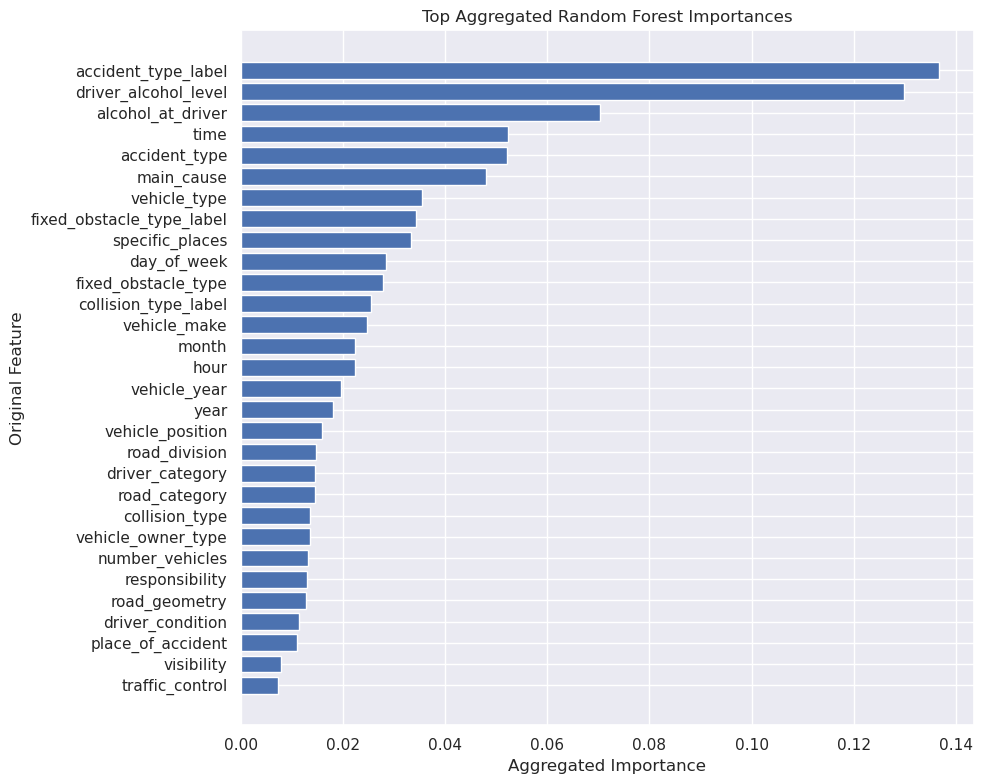

In [ ]:
top_grouped = grouped_fi.head(30).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_grouped["original_feature"], top_grouped["importance"])
plt.xlabel("Aggregated Importance")
plt.ylabel("Original Feature")
plt.title("Top Aggregated Random Forest Importances")
plt.tight_layout()
plt.show()


# Permutation importance


In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean, # type: ignore
    "importance_std": perm_result.importances_std # type: ignore
}).sort_values("importance_mean", ascending=False)

print(perm_df.head(20))

                         feature  importance_mean  importance_std
37           accident_type_label         0.040105        0.002259
40          driver_alcohol_level         0.033708        0.002836
7              alcohol_at_driver         0.004173        0.000899
27            vehicle_owner_type         0.003944        0.000922
24                  vehicle_type         0.003394        0.000844
32  external_influence_on_driver         0.002958        0.001519
31              driver_condition         0.002522        0.001036
42                          year         0.002431        0.001072
30               driver_category         0.002201        0.001350
43                         month         0.002087        0.001772
6                 responsibility         0.002064        0.000632
44                   day_of_week         0.001422        0.000939
3                  accident_type         0.001307        0.001297
15                 road_division         0.001238        0.000853
19        

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21805 entries, 0 to 21804
Data columns (total 46 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   road_category                 21805 non-null  float64 
 1   road_number                   763 non-null    float64 
 2   time                          21805 non-null  int64   
 3   accident_type                 21805 non-null  int64   
 4   collision_type                21805 non-null  int64   
 5   fixed_obstacle_type           21805 non-null  int64   
 6   responsibility                21805 non-null  int64   
 7   alcohol_at_driver             21805 non-null  int64   
 8   main_cause                    21805 non-null  int64   
 9   road_surface_type             21805 non-null  int64   
 10  road_surface_condition        21805 non-null  int64   
 11  road_condition                21805 non-null  int64   
 12  weather_conditions            21805 non-null  

# SHAP analysis

SHAP anlaysis doesn't require pipeline

### Model creation


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

categorical_cols_cb = X.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_indices = [X.columns.get_loc(col) for col in categorical_cols_cb]

model_cb = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=100,
    random_seed=42
)

model_cb.fit(
    X_train, y_train,
    cat_features=categorical_indices,
    eval_set=(X_test, y_test),
    use_best_model=True
)

preds = model_cb.predict(X_test)
print(classification_report(y_test, preds))

0:	test: 0.9288166	best: 0.9288166 (0)	total: 24.1ms	remaining: 12s
100:	test: 0.9559692	best: 0.9559692 (100)	total: 1.65s	remaining: 6.51s
200:	test: 0.9591314	best: 0.9591314 (200)	total: 3.54s	remaining: 5.27s
300:	test: 0.9604259	best: 0.9604285 (297)	total: 5.48s	remaining: 3.63s
400:	test: 0.9610045	best: 0.9610201 (399)	total: 7.73s	remaining: 1.91s
499:	test: 0.9614302	best: 0.9614498 (494)	total: 9.33s	remaining: 0us

bestTest = 0.9614498382
bestIteration = 494

Shrink model to first 495 iterations.
                      precision    recall  f1-score   support

     Injury/Fatality       0.83      0.81      0.82      1236
Material Damage Only       0.92      0.93      0.93      3125

            accuracy                           0.90      4361
           macro avg       0.88      0.87      0.87      4361
        weighted avg       0.90      0.90      0.90      4361



In [ ]:
cb_importance = model_cb.get_feature_importance()
cb_fi_df = pd.DataFrame({
    "feature": X.columns,
    "importance": cb_importance
}).sort_values("importance", ascending=False)

print(cb_fi_df.head(20))

                    feature  importance
37      accident_type_label   14.210249
3             accident_type   11.958897
41  driver_alcohol_detected    7.823214
5       fixed_obstacle_type    6.293000
7         alcohol_at_driver    5.760736
8                main_cause    4.262308
24             vehicle_type    4.088213
21          number_vehicles    3.964927
2                      time    2.920444
38     collision_type_label    2.849391
25             vehicle_make    2.728961
26             vehicle_year    2.626618
40     driver_alcohol_level    2.275895
6            responsibility    2.253421
27       vehicle_owner_type    2.218317
43                    month    2.005009
42                     year    1.753408
0             road_category    1.673746
29         vehicle_position    1.609363
19          specific_places    1.586561


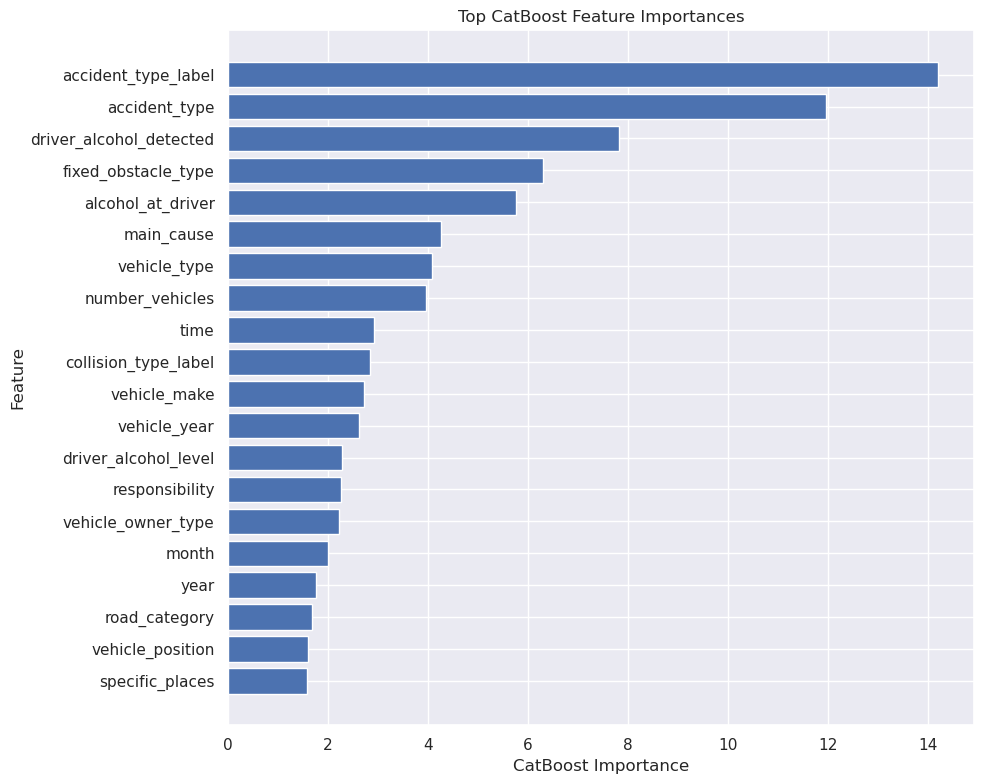

In [ ]:
top_cb = cb_fi_df.head(20).sort_values("importance")

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 8))
plt.barh(top_cb["feature"], top_cb["importance"])
plt.xlabel("CatBoost Importance")
plt.ylabel("Feature")
plt.title("Top CatBoost Feature Importances")
plt.tight_layout()
plt.show()

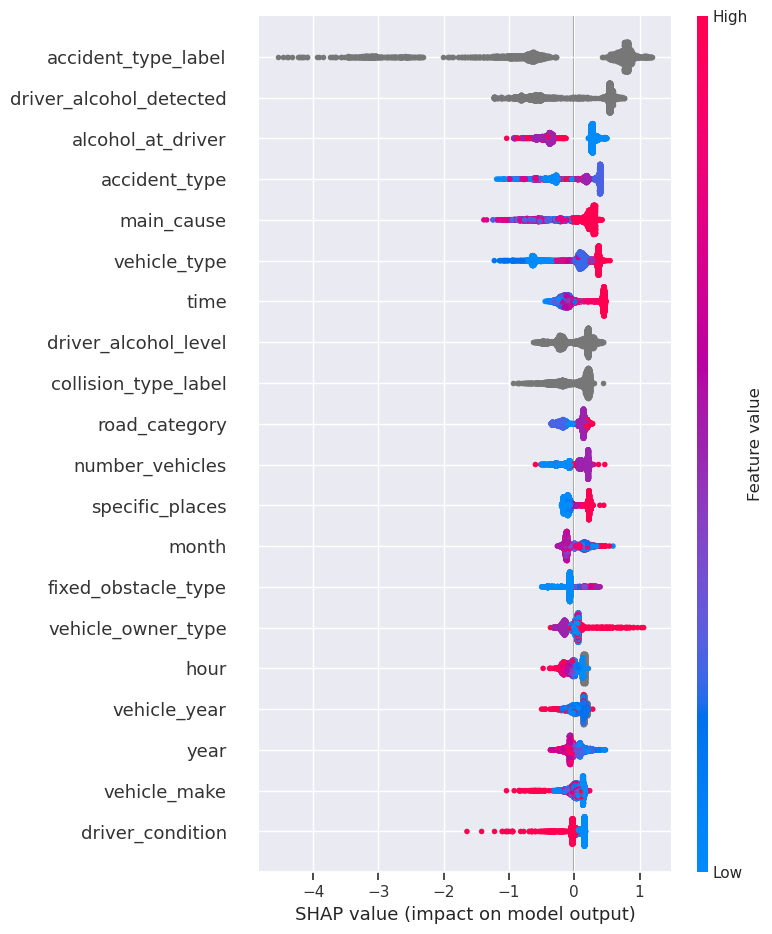

                    feature  importance
37      accident_type_label    0.936823
41  driver_alcohol_detected    0.592435
7         alcohol_at_driver    0.362082
3             accident_type    0.349404
8                main_cause    0.311770
24             vehicle_type    0.285955
2                      time    0.228358
40     driver_alcohol_level    0.216955
38     collision_type_label    0.200623
0             road_category    0.167667
21          number_vehicles    0.158394
19          specific_places    0.141895
43                    month    0.135564
5       fixed_obstacle_type    0.127082
27       vehicle_owner_type    0.101627
45                     hour    0.101228
26             vehicle_year    0.097051
42                     year    0.094152
25             vehicle_make    0.092587
31         driver_condition    0.090240


In [ ]:
import shap

explainer = shap.TreeExplainer(model_cb)
shap_values = explainer.shap_values(X_test)

# for binary classification, shap_values can be list or array depending on version
shap.summary_plot(shap_values, X_test)
import numpy as np
import pandas as pd

shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

print(shap_df.head(20))

The SHAP analysis indicates that accident type is the most influential predictor in the model. The variable accident_type_label has the highest mean absolute SHAP value, suggesting that the nature of the accident itself strongly influences the predicted accident severity. This result is intuitive, as certain accident types are inherently associated with higher risks of injuries or fatalities.

The presence of alcohol-related variables among the most important predictors is also notable. Both driver_alcohol_detected and alcohol_at_driver appear among the top features, indicating that alcohol involvement significantly contributes to the model's prediction of accident severity. This finding aligns with existing research that identifies alcohol impairment as a major factor in severe traffic accidents.

The variable main_cause is also highly ranked, suggesting that the underlying cause of the accident (such as driver inattention, speeding, or failure to yield) plays a substantial role in determining accident outcomes.

Several vehicle-related variables appear in the top features, including vehicle_type, vehicle_owner_type, vehicle_year, and vehicle_make. These variables may capture differences in vehicle characteristics, safety features, or usage patterns that influence accident severity.